# 13.2.2 结构、阈值与剩余功能

## 学习目标与先修知识

分别改变连接和容忍阈值，比较级联与剩余连通功能。

先修：13.2.1 同步阈值级联；11.1 连通分量（connected component）。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

同样的损伤种子和阈值，换网络连接会改变继发失效吗？即使节点幸存，剩余网络是否仍能完成原来的任务？

In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style, show_table
plot_style()
font_names = {font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei", "SimHei", "Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"] = [name, "DejaVu Sans"]
        break
BLUE, PINK, GREEN = "#008bfb", "#ff0051", "#00a56a"

## 初步实验

比较六节点链与以0为中心的星，初始都损伤0；节点2需要两个失效邻居，其余节点阈值为1。先预测终局。

In [2]:
n=6
chain=[[i,i+1] for i in range(n-1)]
star=[[0,i] for i in range(1,n)]
thresholds=[1,1,2,1,1,1]
print('链和星都含',len(chain),'条边；相同种子0、相同阈值表')

链和星都含 5 条边；相同种子0、相同阈值表


## 模型假设

保持六个节点、五条边、各节点阈值和种子0不变，先只改变结构；再在固定星形结构上整体提高阈值。这里的“功能”仅定义为剩余最大连通分量占原节点数的比例，真实处理容量和需求另需建模。

## 数学解释与推导

设终局失效集为 $F_\infty$，幸存图由 $V\setminus F_\infty$ 及两端都幸存的边诱导。定义功能代理 $G=|C_{\max}|/N$，分母保持原节点数。该指标测量连通剩余范围，却不保证处理容量充足。固定图与种子时，逐节点提高阈值只会减少或保持最终失效集合；这可用逐轮集合包含关系归纳证明，但最大分量比例未必严格增加。

## 核心实现

下面将本节推导写成可运行函数。

In [3]:
def threshold_cascade(n, edges, thresholds, seeds):
    """Synchronous failed-neighbor count rule; rounds[0] is direct damage."""
    neighbors = [set() for _ in range(n)]
    for a, b in edges:
        neighbors[a].add(b)
        neighbors[b].add(a)
    failed = set(seeds)
    rounds = [sorted(failed)]
    while True:
        added = [i for i in range(n) if i not in failed
                 and sum(j in failed for j in neighbors[i]) >= thresholds[i]]
        if not added:
            return rounds
        failed.update(added)
        rounds.append(sorted(added))


def largest_survivor_fraction(n, edges, failed):
    """Largest connected surviving component divided by the original n."""
    alive = set(range(n)) - set(failed)
    neighbors = {i: set() for i in alive}
    for a, b in edges:
        if a in alive and b in alive:
            neighbors[a].add(b)
            neighbors[b].add(a)
    largest = 0
    while alive:
        start = alive.pop()
        seen = {start}
        frontier = [start]
        while frontier:
            for node in neighbors[frontier.pop()]:
                if node in alive:
                    alive.remove(node)
                    seen.add(node)
                    frontier.append(node)
        largest = max(largest, len(seen))
    return largest / n

## 对照实验

分别计算链、星及星形高阈值三个条件，显示直接/继发失败和剩余最大分量。

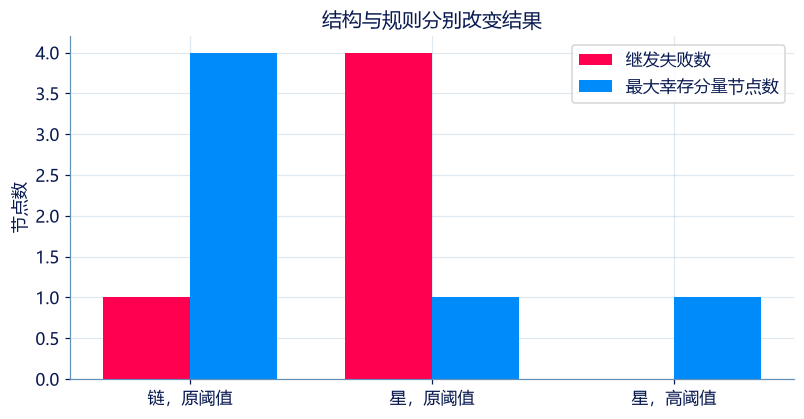

条件 / 继发数 / G / 轮次： [('链，原阈值', 1, 0.6666666666666666, [[0], [1]]), ('星，原阈值', 4, 0.16666666666666666, [[0], [1, 3, 4, 5]]), ('星，高阈值', 0, 0.16666666666666666, [[0]])]


In [4]:
conditions=[('链，原阈值',chain,thresholds),('星，原阈值',star,thresholds),('星，高阈值',star,[2]*n)]
rows=[]
for name,edges,limits in conditions:
    rounds=threshold_cascade(n,edges,limits,[0]);failed={x for row in rounds for x in row}
    rows.append((name,len(failed)-1,largest_survivor_fraction(n,edges,failed),rounds))
fig,ax=plt.subplots(figsize=(7.2,3.7));x=np.arange(len(rows))
ax.bar(x-.18,[r[1] for r in rows],width=.36,label='继发失败数',color=PINK)
ax.bar(x+.18,[n*r[2] for r in rows],width=.36,label='最大幸存分量节点数',color=BLUE)
ax.set(xticks=x,xticklabels=[r[0] for r in rows],ylabel='节点数',title='结构与规则分别改变结果')
ax.legend();plt.show()
print('条件 / 继发数 / G / 轮次：',rows)

## 结果解释

相同边数并不等于相同传播路径。连通最大分量是公开的教学代理；若任务需要容量、路径长度或特定端点，还需为那些功能单独建模。

### 独立核对

手算链与星的新增集合；验证完全失效和孤立节点的分母定义。

In [5]:
assert rows[0][3]==[[0],[1]]
assert rows[1][3]==[[0],[1,3,4,5]]
assert rows[2][3]==[[0]]
assert largest_survivor_fraction(3,[[0,1],[1,2]],[0,1,2])==0.
assert largest_survivor_fraction(3,[],[0])==1/3
print('结构、阈值及功能边界核对通过。')

结构、阈值及功能边界核对通过。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/13-02-%E7%BA%A7%E8%81%94%E5%A4%B1%E6%95%88%E4%B8%8E%E7%BB%93%E6%9E%84%E9%B2%81%E6%A3%92%E6%80%A7/explore/)：先预测结果，再比较图形与数值。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：计算剩余网络的功能代理

失效节点及其相邻边不再可用。返回剩余图最大连通分量（connected component）的节点数除以原节点数 n；这是本题定义的功能代理，不是所有真实网络的功能。

**函数与代码模板**

```python
def solve(
    n: int,
    edges: list[list[int]],
    failed: list[int],
) -> float:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `n` | `int` | 原网络节点数。 | 节点 |
| `edges` | `list[list[int]]` | 原无向边。 | 边 |
| `failed` | `list[int]` | 已失效节点。 | 节点编号 |

**返回值**

直接返回 fraction（float）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `fraction` | `float` | 最大剩余连通分量占原节点数的比例。 | 无量纲 |

**计算规则**

失效节点不计入剩余分量；完全失效返回0；孤立剩余节点各自构成大小1的分量。

**约束与边界**

- 所有比较使用题定模型（model）和相同单位；仅输出（output）函数返回值，不依赖外部文件。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| n | 原网络节点数。 | 4 | 节点 |
| edges | 原无向边。 | [[0, 1], [1, 2], [2, 3]] | 边 |
| failed | 已失效节点。 | [1] | 节点编号 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
n = 4
edges = [[0, 1], [1, 2], [2, 3]]
failed = [1]

result = solve(n, edges, failed)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| fraction | 最大剩余连通分量占原节点数的比例。 | 0.5 | 无量纲 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = 0.5
```

**样例解释**

去掉链的内部节点后，最大剩余分量仍可能含多个节点；分母始终是原 n。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：计算剩余网络的功能代理](http://127.0.0.1:8000/chapters/13-02-%E7%BA%A7%E8%81%94%E5%A4%B1%E6%95%88%E4%B8%8E%E7%BB%93%E6%9E%84%E9%B2%81%E6%A3%92%E6%80%A7/practice/?question=p13-largest-survivor)

### 第 2 题 · 单项选择题：连通不保证功能

一个剩余网络仍连通，但所有剩余节点的实际处理容量都降到需求以下。哪项成立？

- **A.** 连通性代理仍可能为正，真实负载功能却可能失效。
- **B.** 连通就保证所有任务可完成。
- **C.** 最大分量比例必为0。
- **D.** 必须把所有节点恢复才能定义功能。

[作答：连通不保证功能](http://127.0.0.1:8000/chapters/13-02-%E7%BA%A7%E8%81%94%E5%A4%B1%E6%95%88%E4%B8%8E%E7%BB%93%E6%9E%84%E9%B2%81%E6%A3%92%E6%80%A7/practice/?question=p13-connected-not-functional)

### 第 3 题 · 单项选择题：区分结构和阈值

比较新增边和提高阈值两种干预对最终损失的影响，哪项设计最清楚？

- **A.** 固定同一初始损伤和另一因素，分别只改变结构或阈值。
- **B.** 结构、阈值和种子都同时更换。
- **C.** 只比较两张图的视觉稠密程度。
- **D.** 把第0轮损伤也算作新增边的影响。

[作答：区分结构和阈值](http://127.0.0.1:8000/chapters/13-02-%E7%BA%A7%E8%81%94%E5%A4%B1%E6%95%88%E4%B8%8E%E7%BB%93%E6%9E%84%E9%B2%81%E6%A3%92%E6%80%A7/practice/?question=p13-control-one-factor)

### 第 4 题 · 单项选择题：提高阈值后的边界

在相同图与相同种子下，仅逐节点提高正整数阈值，以下哪项对本题不可逆同步规则成立？

- **A.** 最终失效集合不会比原来更大。
- **B.** 最终失效集合一定严格缩小。
- **C.** 第0轮种子会自动减少。
- **D.** 最大连通分量（connected component）一定严格增大。

[作答：提高阈值后的边界](http://127.0.0.1:8000/chapters/13-02-%E7%BA%A7%E8%81%94%E5%A4%B1%E6%95%88%E4%B8%8E%E7%BB%93%E6%9E%84%E9%B2%81%E6%A3%92%E6%80%A7/practice/?question=p13-threshold-monotonic)

**进一步阅读**

[Network Science 在线教材](https://networksciencebook.com/translations/en/partials/chapter.html)提供网络鲁棒性的广义背景；本节功能代理由题内定义。